In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate

In [2]:
def f(x):
    return 4 / (1 + x**2)

m_values = np.arange(1, 26)
pi_true = np.pi

In [3]:
h_values = []

mid_vals = []
trap_vals = []
simp_vals = []

mid_err = []
trap_err = []
simp_err = []

eval_mid = []
eval_trap = []
eval_simp = []

In [4]:
for m in m_values:
    n = 2**m
    h = 1 / n
    x = np.linspace(0, 1, n + 1)

    x_mid = (x[:-1] + x[1:]) / 2
    I_mid = h * np.sum(f(x_mid))

    I_trap = integrate.trapezoid(f(x), x)

    I_simp = integrate.simpson(f(x), x=x)

    h_values.append(h)

    mid_vals.append(I_mid)
    trap_vals.append(I_trap)
    simp_vals.append(I_simp)

    mid_err.append(abs((I_mid - pi_true) / pi_true))
    trap_err.append(abs((I_trap - pi_true) / pi_true))
    simp_err.append(abs((I_simp - pi_true) / pi_true))

    eval_mid.append(len(x_mid))
    eval_trap.append(len(x))
    eval_simp.append(len(x))

In [5]:
h_values = np.array(h_values)

mid_err = np.array(mid_err)
trap_err = np.array(trap_err)
simp_err = np.array(simp_err)

eval_mid = np.array(eval_mid)
eval_trap = np.array(eval_trap)
eval_simp = np.array(eval_simp)

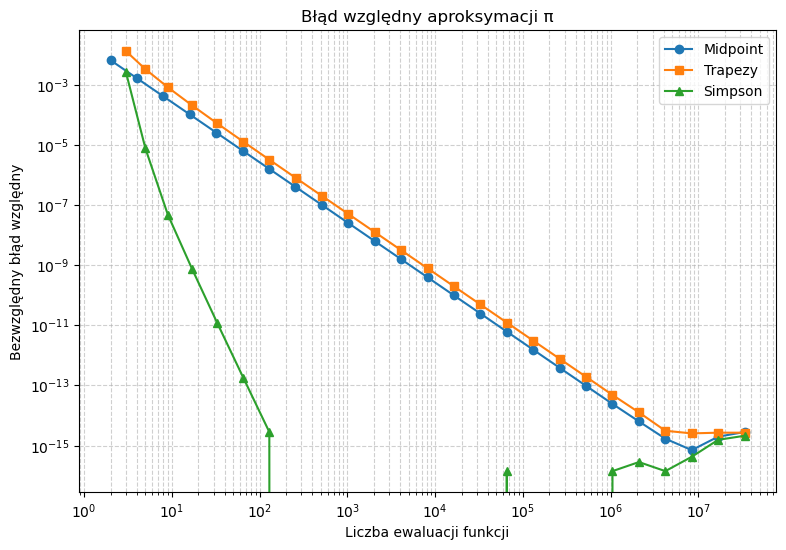

In [6]:
plt.figure(figsize=(9, 6))

plt.loglog(eval_mid, mid_err, 'o-', label='Midpoint')
plt.loglog(eval_trap, trap_err, 's-', label='Trapezy')
plt.loglog(eval_simp, simp_err, '^-', label='Simpson')

plt.xlabel('Liczba ewaluacji funkcji')
plt.ylabel('Bezwzględny błąd względny')
plt.title('Błąd względny aproksymacji π')
plt.grid(True, which='both', ls='--', alpha=0.6)
plt.legend()
plt.show()

In [7]:
for i in range(len(m_values)):
    print(
        f"m={m_values[i]:2d}, "
        f"h={h_values[i]:.3e}, "
        f"mid_err={mid_err[i]:.3e}, "
        f"trap_err={trap_err[i]:.3e}, "
        f"simp_err={simp_err[i]:.3e}"
    )

m= 1, h=5.000e-01, mid_err=6.608e-03, trap_err=1.324e-02, simp_err=2.629e-03
m= 2, h=2.500e-01, mid_err=1.658e-03, trap_err=3.316e-03, simp_err=7.648e-06
m= 3, h=1.250e-01, mid_err=4.145e-04, trap_err=8.289e-04, simp_err=4.811e-08
m= 4, h=6.250e-02, mid_err=1.036e-04, trap_err=2.072e-04, simp_err=7.528e-10
m= 5, h=3.125e-02, mid_err=2.590e-05, trap_err=5.181e-05, simp_err=1.176e-11
m= 6, h=1.562e-02, mid_err=6.476e-06, trap_err=1.295e-05, simp_err=1.838e-13
m= 7, h=7.812e-03, mid_err=1.619e-06, trap_err=3.238e-06, simp_err=2.827e-15
m= 8, h=3.906e-03, mid_err=4.048e-07, trap_err=8.095e-07, simp_err=0.000e+00
m= 9, h=1.953e-03, mid_err=1.012e-07, trap_err=2.024e-07, simp_err=0.000e+00
m=10, h=9.766e-04, mid_err=2.530e-08, trap_err=5.059e-08, simp_err=0.000e+00
m=11, h=4.883e-04, mid_err=6.324e-09, trap_err=1.265e-08, simp_err=0.000e+00
m=12, h=2.441e-04, mid_err=1.581e-09, trap_err=3.162e-09, simp_err=0.000e+00
m=13, h=1.221e-04, mid_err=3.953e-10, trap_err=7.905e-10, simp_err=0.000e+00

In [8]:
idx_mid = np.argmin(mid_err)
idx_trap = np.argmin(trap_err)
idx_simp = np.argmin(simp_err)

print("Midpoint:")
print("  h_min =", h_values[idx_mid])
print("  min błąd =", mid_err[idx_mid])

print("\nTrapezy:")
print("  h_min =", h_values[idx_trap])
print("  min błąd =", trap_err[idx_trap])

print("\nSimpson:")
print("  h_min =", h_values[idx_simp])
print("  min błąd =", simp_err[idx_simp])

Midpoint:
  h_min = 1.1920928955078125e-07
  min błąd = 7.067899292141149e-16

Trapezy:
  h_min = 1.1920928955078125e-07
  min błąd = 2.5444437451708133e-15

Simpson:
  h_min = 0.00390625
  min błąd = 0.0


In [9]:
def empirical_order(h, err):
    return np.log(err[:-1] / err[1:]) / np.log(h[:-1] / h[1:])

In [10]:
p_mid = empirical_order(h_values, mid_err)
p_trap = empirical_order(h_values, trap_err)
p_simp = empirical_order(h_values, simp_err)

C:\Users\maksy\AppData\Local\Temp\ipykernel_10880\1743441464.py:2: RuntimeWarning: divide by zero encountered in divide
  return np.log(err[:-1] / err[1:]) / np.log(h[:-1] / h[1:])
C:\Users\maksy\AppData\Local\Temp\ipykernel_10880\1743441464.py:2: RuntimeWarning: invalid value encountered in divide
  return np.log(err[:-1] / err[1:]) / np.log(h[:-1] / h[1:])
C:\Users\maksy\AppData\Local\Temp\ipykernel_10880\1743441464.py:2: RuntimeWarning: divide by zero encountered in log
  return np.log(err[:-1] / err[1:]) / np.log(h[:-1] / h[1:])


In [11]:
valid_mid = np.arange(max(1, idx_mid - 5))
valid_trap = np.arange(max(1, idx_trap - 5))
valid_simp = np.arange(max(1, idx_simp - 5))

print("Średni rząd empiryczny (przed osiągnięciem minimum błędu):")
print(f"Midpoint ~ {np.mean(p_mid[valid_mid]):.3f}")
print(f"Trapezy  ~ {np.mean(p_trap[valid_trap]):.3f}")
print(f"Simpson  ~ {np.mean(p_simp[valid_simp]):.3f}")

Średni rząd empiryczny (przed osiągnięciem minimum błędu):
Midpoint ~ 2.000
Trapezy  ~ 2.000
Simpson  ~ 7.869


In [12]:
print("Lokalne rzędy Midpoint:")
print(p_mid)

print("\nLokalne rzędy Trapezy:")
print(p_trap)

print("\nLokalne rzędy Simpson:")
print(p_simp)

Lokalne rzędy Midpoint:
[ 1.99506253  1.99987834  1.99999238  1.99999952  1.99999997  2.
  2.          2.          2.          1.99999999  1.99999984  2.
  2.00000155  1.99998762  2.          2.00009906  1.99973584  1.99525342
  1.99369542  1.93441166  1.9068906   1.26303441 -1.48542683 -0.51457317]

Lokalne rzędy Trapezy:
[ 1.99750203  1.9999372   1.99999607  1.99999975  1.99999998  2.
  2.          2.          2.          2.          2.00000008  1.99999974
  2.00000052  1.9999969   2.00002477  2.          2.00006604  1.99498926
  2.00210766  1.92599942  2.03242148  0.28950662 -0.07800251  0.        ]

Lokalne rzędy Simpson:
[ 8.42527443  7.31266056  5.99783394  5.99982717  6.00034676  6.02236781
         inf         nan         nan         nan         nan         nan
         nan         nan        -inf         inf         nan         nan
        -inf -1.          1.         -1.5849625  -1.87446912 -0.44745898]


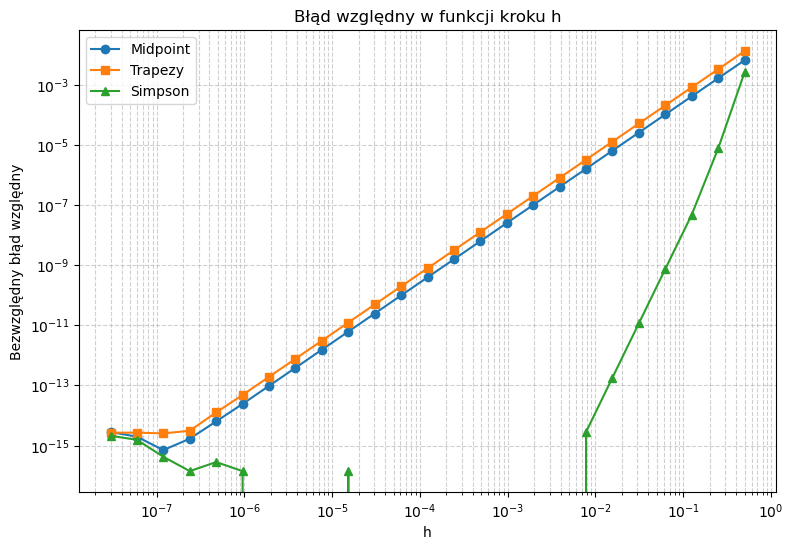

In [13]:
plt.figure(figsize=(9, 6))

plt.loglog(h_values, mid_err, 'o-', label='Midpoint')
plt.loglog(h_values, trap_err, 's-', label='Trapezy')
plt.loglog(h_values, simp_err, '^-', label='Simpson')

plt.xlabel('h')
plt.ylabel('Bezwzględny błąd względny')
plt.title('Błąd względny w funkcji kroku h')
plt.grid(True, which='both', ls='--', alpha=0.6)
plt.legend()
plt.show()

Dla dostatecznie małych h błąd przestaje maleć, ponieważ zaczyna dominować 
błąd numeryczny wynikający z arytmetyki zmiennoprzecinkowej 
(zaokrąglenia i utrata cyfr znaczących).

Rzędy teoretyczne:
Midpoint: 2
Trapezy:  2
Simpson:  4

### zad 2

In [14]:
from numpy.polynomial.legendre import leggauss

gauss_n = np.arange(1, 200)
gauss_err = []
gauss_eval = []
gauss_vals = []

for n in gauss_n:
    xg, wg = leggauss(n)

    x = 0.5 * (xg + 1)
    w = 0.5 * wg

    I_gauss = np.sum(w * f(x))

    gauss_vals.append(I_gauss)
    gauss_err.append(abs((I_gauss - np.pi) / np.pi))
    gauss_eval.append(n)

gauss_err = np.array(gauss_err)
gauss_eval = np.array(gauss_eval)

Początek plateau dla n = 11


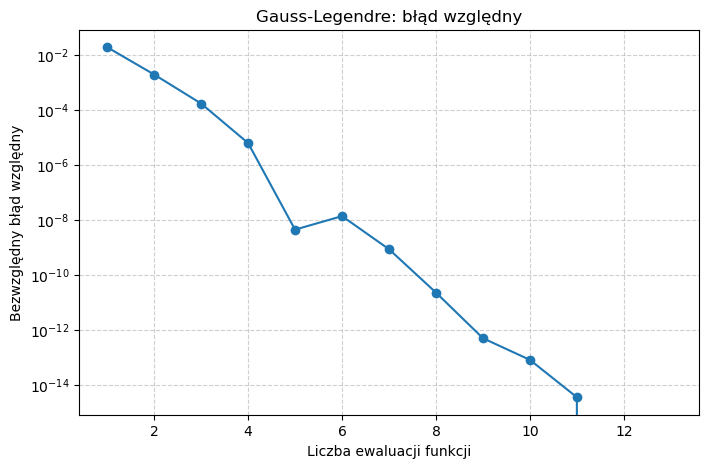

In [15]:
idx_sat = np.argmax(gauss_err < 1e-14)
print("Początek plateau dla n =", gauss_eval[idx_sat])

mask_gauss = gauss_eval <= gauss_eval[idx_sat] + 2

plt.figure(figsize=(8, 5))
plt.semilogy(gauss_eval[mask_gauss], gauss_err[mask_gauss], 'o-')
plt.xlabel('Liczba ewaluacji funkcji')
plt.ylabel('Bezwzględny błąd względny')
plt.title('Gauss-Legendre: błąd względny')
plt.grid(True, which='both', ls='--', alpha=0.6)
plt.show()

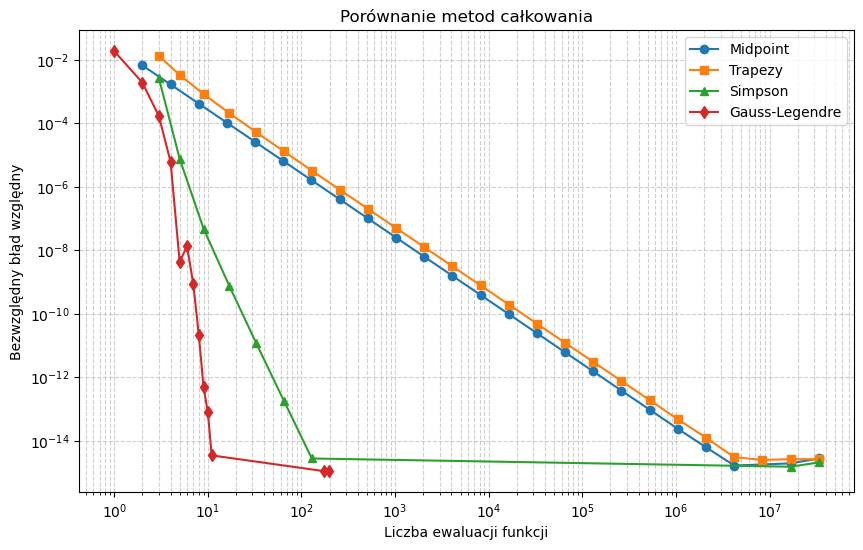

In [16]:
mask_mid = mid_err > 1e-15
mask_trap = trap_err > 1e-15
mask_simp = simp_err > 1e-15
mask_gauss = gauss_err > 1e-15

plt.figure(figsize=(10, 6))

plt.loglog(eval_mid[mask_mid], mid_err[mask_mid], 'o-', label='Midpoint')
plt.loglog(eval_trap[mask_trap], trap_err[mask_trap], 's-', label='Trapezy')
plt.loglog(eval_simp[mask_simp], simp_err[mask_simp], '^-', label='Simpson')
plt.loglog(gauss_eval[mask_gauss], gauss_err[mask_gauss], 'd-', label='Gauss-Legendre')

plt.xlabel('Liczba ewaluacji funkcji')
plt.ylabel('Bezwzględny błąd względny')
plt.title('Porównanie metod całkowania')
plt.grid(True, which='both', ls='--', alpha=0.6)
plt.legend()
plt.show()

Metoda Gaussa-Legendre’a osiąga dużo mniejszy błąd przy tej samej liczbie 
ewaluacji funkcji niż kwadratury złożone z punktu (a). Dla większej liczby
węzłów dalsze zwiększanie n przestaje poprawiać wynik, ponieważ zaczyna
dominować błąd numeryczny arytmetyki zmiennoprzecinkowej.

## zad 3

In [17]:
from scipy.integrate import quad_vec

tols = 10.0 ** (-np.arange(0, 15))   # 10^0, 10^-1, ..., 10^-14

trap_adapt_err = []
trap_adapt_eval = []

gk_err = []
gk_eval = []

for tol in tols:
    # adaptacyjne trapezy
    res_t, err_t, info_t = quad_vec(
        f, 0.0, 1.0,
        epsrel=tol,
        epsabs=0.0,
        quadrature='trapezoid',
        full_output=True
    )
    trap_adapt_err.append(abs((res_t - np.pi) / np.pi))
    trap_adapt_eval.append(info_t.neval)

    # adaptacyjny Gauss-Kronrod
    res_gk, err_gk, info_gk = quad_vec(
        f, 0.0, 1.0,
        epsrel=tol,
        epsabs=0.0,
        quadrature='gk21',
        full_output=True
    )
    gk_err.append(abs((res_gk - np.pi) / np.pi))
    gk_eval.append(info_gk.neval)

trap_adapt_err = np.array(trap_adapt_err)
trap_adapt_eval = np.array(trap_adapt_eval)

gk_err = np.array(gk_err)
gk_eval = np.array(gk_eval)

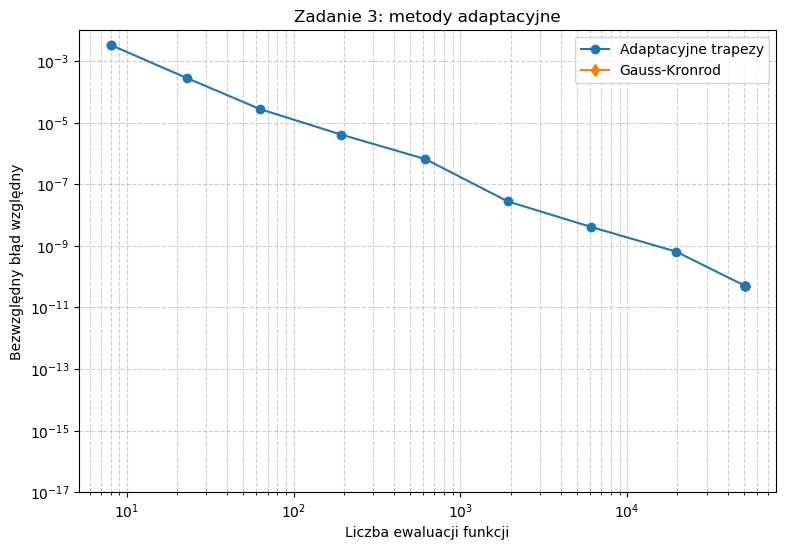

In [18]:
plt.figure(figsize=(9, 6))

plt.loglog(trap_adapt_eval, trap_adapt_err, 'o-', label='Adaptacyjne trapezy')
plt.loglog(gk_eval, gk_err, 'd-', label='Gauss-Kronrod')

plt.ylim(1e-17, 1e-2)
plt.xlabel('Liczba ewaluacji funkcji')
plt.ylabel('Bezwzględny błąd względny')
plt.title('Zadanie 3: metody adaptacyjne')
plt.grid(True, which='both', ls='--', alpha=0.6)
plt.legend()
plt.show()

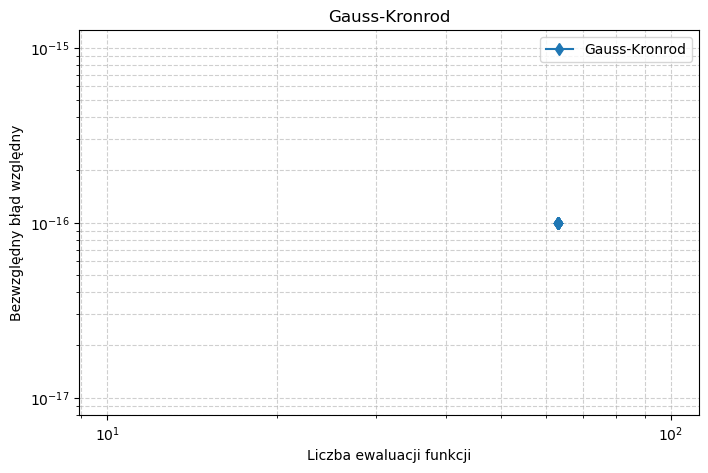

In [19]:
gk_err_plot = np.maximum(gk_err, 1e-16)

plt.figure(figsize=(8, 5))
plt.loglog(gk_eval, gk_err_plot, 'd-', label='Gauss-Kronrod')
plt.xlabel('Liczba ewaluacji funkcji')
plt.ylabel('Bezwzględny błąd względny')
plt.title('Gauss-Kronrod')
plt.grid(True, which='both', ls='--', alpha=0.6)
plt.legend()
plt.show()

Dla adaptacyjnej kwadratury Gaussa-Kronroda uzyskany błąd względny 
osiąga dokładność maszynową i w obliczeniach zmiennoprzecinkowych 
przyjmuje wartość 0. Z tego powodu przy rysowaniu na skali logarytmicznej
zera zastąpiono bardzo małą dodatnią wartością.

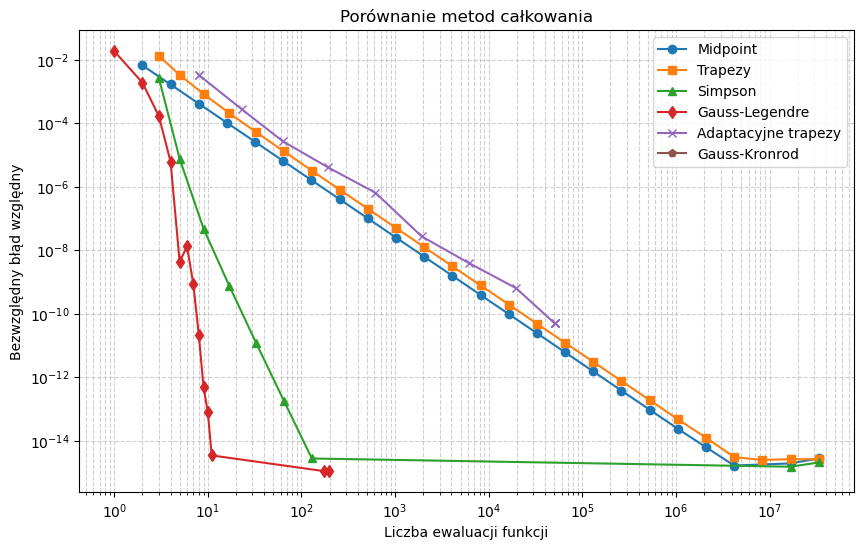

In [20]:
mask_mid = mid_err > 1e-15
mask_trap = trap_err > 1e-15
mask_simp = simp_err > 1e-15
mask_gauss = gauss_err > 1e-15
mask_trap_adapt = trap_adapt_err > 1e-15
mask_gk = gk_err > 1e-15

plt.figure(figsize=(10, 6))

plt.loglog(eval_mid[mask_mid], mid_err[mask_mid], 'o-', label='Midpoint')
plt.loglog(eval_trap[mask_trap], trap_err[mask_trap], 's-', label='Trapezy')
plt.loglog(eval_simp[mask_simp], simp_err[mask_simp], '^-', label='Simpson')
plt.loglog(gauss_eval[mask_gauss], gauss_err[mask_gauss], 'd-', label='Gauss-Legendre')

plt.loglog(trap_adapt_eval[mask_trap_adapt], trap_adapt_err[mask_trap_adapt], 'x-', label='Adaptacyjne trapezy')
plt.loglog(gk_eval[mask_gk], gk_err[mask_gk], 'p-', label='Gauss-Kronrod')

plt.xlabel('Liczba ewaluacji funkcji')
plt.ylabel('Bezwzględny błąd względny')
plt.title('Porównanie metod całkowania')
plt.grid(True, which='both', ls='--', alpha=0.6)
plt.legend()
plt.show()

Metody adaptacyjne zmieniają liczbę podprzedziałów zależnie od zadanej tolerancji. 
Wraz ze zmniejszaniem tolerancji rośnie liczba ewaluacji funkcji, a błąd maleje aż do
momentu osiągnięcia granicy dokładności maszynowej. Adaptacyjna kwadratura
Gaussa-Kronroda osiąga zadaną dokładność przy mniejszej liczbie ewaluacji funkcji
niż adaptacyjna metoda trapezów.

## zad 4

In [21]:
rng = np.random.default_rng(123)

mc_n = np.unique(np.logspace(1, 7, 30, dtype=int))
mc_err = []
mc_vals = []

for n in mc_n:
    x = rng.random(n)
    I_mc = np.mean(f(x))

    mc_vals.append(I_mc)
    mc_err.append(abs((I_mc - np.pi) / np.pi))

mc_vals = np.array(mc_vals)
mc_err = np.array(mc_err)

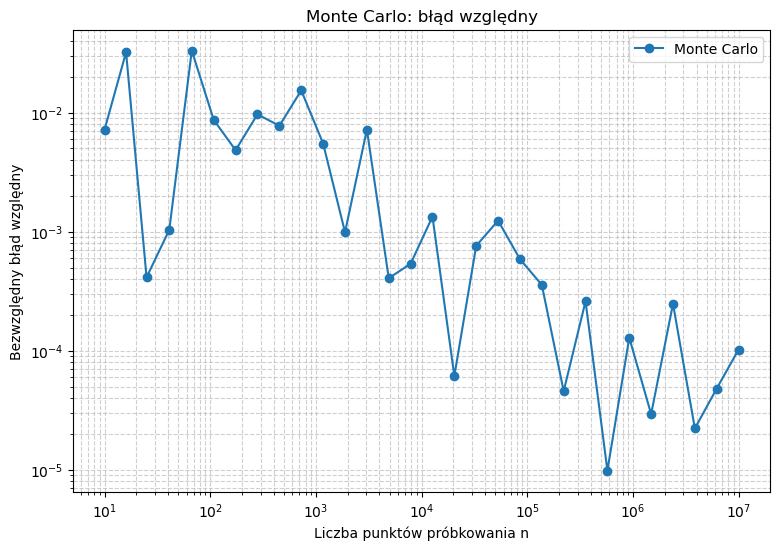

In [22]:
plt.figure(figsize=(9, 6))
plt.loglog(mc_n, mc_err, 'o-', label='Monte Carlo')

plt.xlabel('Liczba punktów próbkowania n')
plt.ylabel('Bezwzględny błąd względny')
plt.title('Monte Carlo: błąd względny')
plt.grid(True, which='both', ls='--', alpha=0.6)
plt.legend()
plt.show()


W metodzie Monte Carlo błąd maleje wraz ze wzrostem liczby punktów próbkowania, 
ale znacznie wolniej niż w klasycznych kwadraturach numerycznych. 
Teoretycznie błąd metody Monte Carlo maleje jak O(n^(-1/2)), 
dlatego do uzyskania wysokiej dokładności potrzeba bardzo dużej liczby próbek.
